/tmp/ipykernel_10758/614007751.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(r.importances[sorted_idx].T, vert=False, labels=sorted_idx)


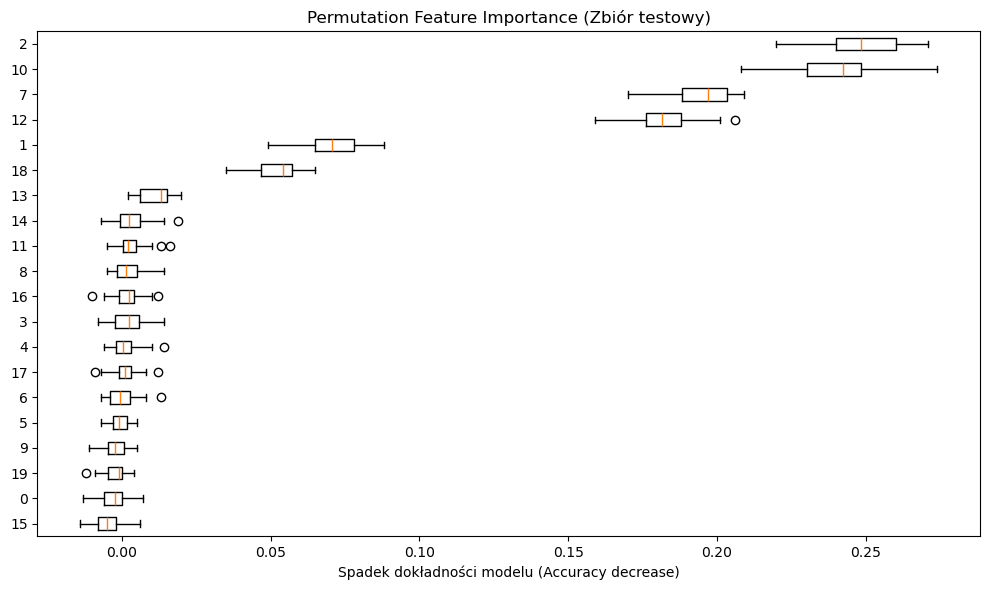

In [ ]:
#Permutation Feature Importance
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

X, y = make_classification(n_samples=5000, n_features=20, n_classes=4, n_informative=4)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

class PyTorchClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.model = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )
        self.classes_ = np.array([0, 1, 2, 3]) 
        
    def fit(self, X, y):
        X_t = torch.as_tensor(X, dtype=torch.float32)
        y_t = torch.as_tensor(y, dtype=torch.long)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)#aktualizacja wag w oparciu o bledy
        
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            outputs = self.model(X_t)
            loss = criterion(outputs, y_t)
            loss.backward()
            optimizer.step()
        return self
        
    def predict(self, X):
        X_t = torch.as_tensor(X, dtype=torch.float32)
        with torch.no_grad():
            outputs = self.model(X_t)
            return torch.argmax(outputs, dim=1).numpy()

clf = PyTorchClassifierWrapper(epochs=100)
clf.fit(X_train_val, y_train_val)

r = permutation_importance(clf, X_test.numpy(), y_test.numpy(), n_repeats=30, random_state=0)

sorted_idx = r.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(r.importances[sorted_idx].T, vert=False, labels=sorted_idx)
ax.set_title("Permutation Feature Importance (Zbiór testowy)")
ax.set_xlabel("Spadek dokładności mn_repeats=odelu (Accuracy decrease)")
fig.tight_layout()
plt.show()